# Exploratory Data Analysis (EDA)

In [185]:
#Importing libraries
import pandas as pd
import numpy as np

In [186]:
# 1.1 loading the dataset 
df=pd.read_csv('placementdata.csv')

In [187]:
# 1.2 Displaying the first 5 rows
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


#### 1.3 Data Dictionary

Before diving into the analysis, Let's break down our dataset and understand what each column actually means.

| Column Name | Data Type | Description | Values / Range |
| :--- | :--- | :--- | :--- |
| **sl_no** | Integer | Serial Number (Candidate ID) | Unique identifier |
| **gender** | Categorical | Candidate Gender | `M` (Male), `F` (Female) |
| **ssc_p** | Numeric | 10th Grade (Secondary School) Percentage | 0% – 100% |
| **ssc_b** | Categorical | 10th Grade Board of Education | `Central`, `Others` |
| **hsc_p** | Numeric | 12th Grade (Higher Secondary) Percentage | 0% – 100% |
| **hsc_b** | Categorical | 12th Grade Board of Education | `Central`, `Others` |
| **hsc_s** | Categorical | Specialization in 12th Grade | `Commerce`, `Science`, `Arts` |
| **degree_p** | Numeric | Under-Graduation (Degree) Percentage | 0% – 100% |
| **degree_t** | Categorical | Under-Graduation Degree Type / Field | `Sci&Tech`, `Comm&Mgmt`, `Others` |
| **workex** | Categorical | Prior Professional Work Experience | `Yes`, `No` |
| **etest_p** | Numeric | College Employability Test Percentage | 0% – 100% |
| **specialisation**| Categorical | Post-Graduation (MBA) Specialization | `Mkt&HR`, `Mkt&Fin` |
| **mba_p** | Numeric | MBA Graduation Percentage | 0% – 100% |
| **status** | Categorical | **Target Variable:** Placement Status | `Placed`, `Not Placed` |
| **salary** | Numeric | Annual Salary Offered by Corporates | Currency units (NaN if Unplaced) |

---

### Step 2 : Data Structure and size

In [188]:
# 2.1 Dataset Dimensions
print('Shape of the dataset is:',df.shape)
print('Total rows (students) are:', df.shape[0])
print('Total columns (features) are:', df.shape[1])

Shape of the dataset is: (215, 15)
Total rows (students) are: 215
Total columns (features) are: 15


In [189]:
# 2.2 Data types and missing values 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


> **Quick Observation:** The dataset contains 215 entries (rows). The Salary column has 148 entries, while all other columns have complete entries. That means we have 67 missing values here. This makes perfect sense because unplaced students do not have a corporate salary! We will deal with this in the data cleaning section.

In [190]:
# 2.3 Summary Statistics
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


> **Quick Observation (Summary Statistics):** 
> * **Academic Grades:** The average percentages across school (ssc_p ~67.3%), high school (hsc_p ~66.3%), and college (degree_p ~66.3%) are remarkably consistent, whereas the MBA averages (mba_p ~62.2%) are slightly tighter and lower.
> * **Salary Distribution:** The minimum salary offered is **200,000**, the median is **265,000**, but there's a huge maximum outlier at **940,000**.

In [191]:
# 2.4 Missing Values
print('Total missing values: ',df.isnull().sum())

Total missing values:  sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64


In [192]:
# 2.5 Duplicate records
print('Total duplicate rows:',df.duplicated().sum())

Total duplicate rows: 0


---
### Step 3: Data Cleaning

Based on the initial findings, we must do two steps before diving into visualizations:
1. Handle the 67 missing values in the 'salary' column by replacing them with 0 as students who were not placed do not have salary records.
2. Drop the 'sl_no' column because a serial number acts like an index and has no contribution for our target outcome

In [193]:
# 3.1 Replacing NaN values
df['salary'] = df['salary'].fillna(0)

In [194]:
# 3.2 Dropping the 'sl_no' column
df = df.drop(columns=['sl_no'])

In [195]:
# 3.3 Verify changes: checking remaining null values and column names
print('Remaining Null Values')
print(df.isnull().sum())

print('\n Updated Columns List')
print(df.columns.tolist())

Remaining Null Values
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

 Updated Columns List
['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'salary']


---
### Step 4 : Visualizations and Analysis

In [196]:
#Importing required libraries
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [197]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor']='#00000000'

#### 4.1 Univariate Analysis
Univariate analysis is performed to understand the distribution of individual variables in the dataset. It helps identify the frequency of categorical variables and the distribution of numerical variables before studying relationships between different features.

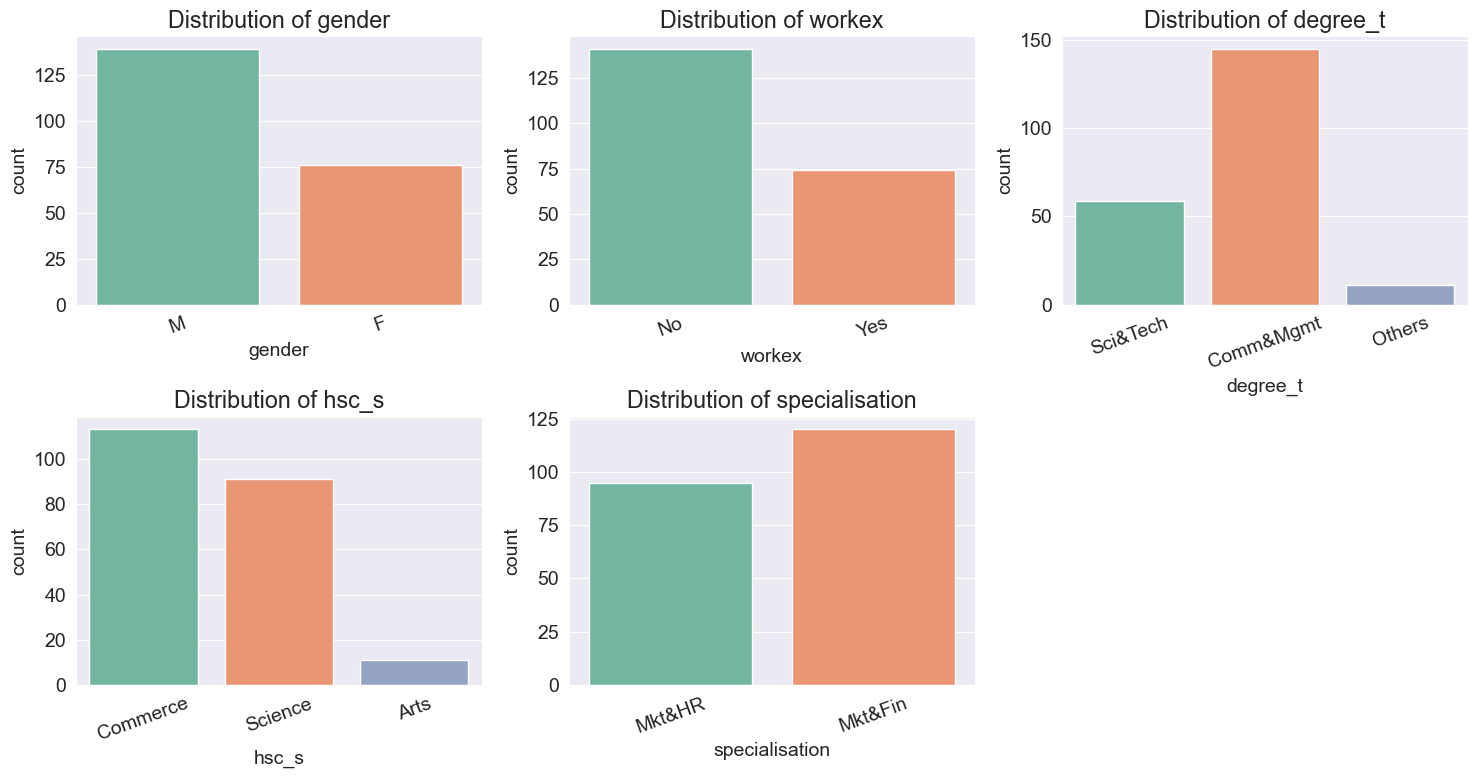

In [198]:
## 4.1.1 Distribution of Categorical Features
categorical_cols = ['gender', 'workex', 'degree_t', 'hsc_s', 'specialisation']

plt.figure(figsize=(15,8))

for i, col in enumerate(categorical_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(
    x=col,
    data=df,
    hue=col,
    palette='Set2',
    legend=False
)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

>  **Quick Observation (Categorical Distribution Analysis):**
> * **Gender & Workex:** The dataset clearly contains more male candidates and individuals with no prior experience.
> * **Dominating Streams:** Commerce and Management fields dominate this batch heavily. `Comm&Mgmt` overwhelmingly dominates undergraduate degrees, while `Commerce` and `Science` almost entirely make up the high school streams (`hsc_s`), leaving `Arts` as a very tiny minority.
> * **Specializations:** The MBA specialisation split is fairly healthy with `Mkt&Fin` slightly ahead of `Mkt&HR`.

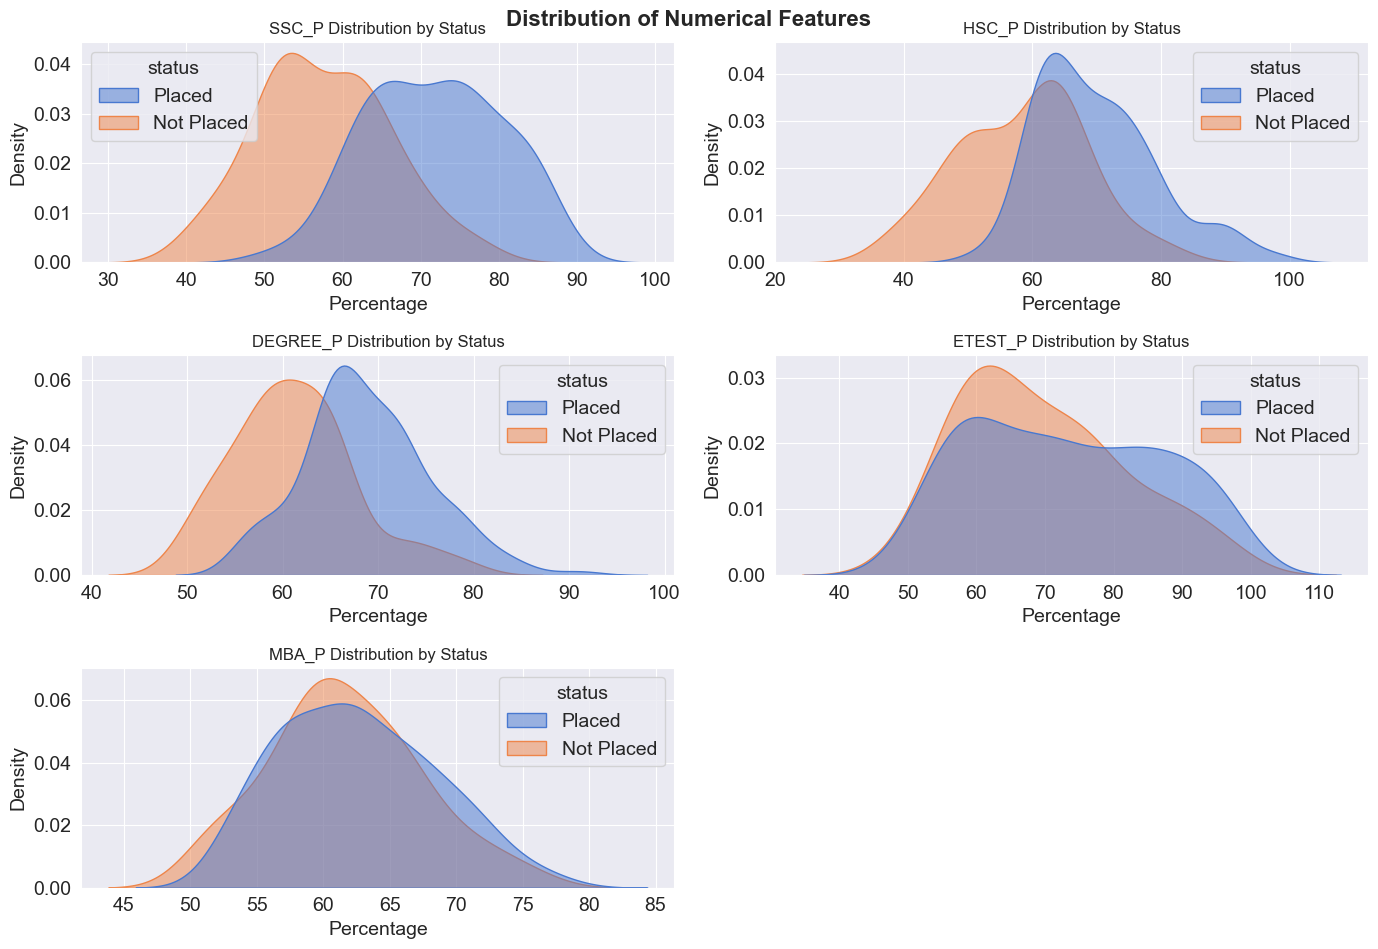

In [201]:
## 4.1.2 Distribution of Numerical Features
plt.figure(figsize=(14, 10))
plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=0.95)

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i)
    sns.kdeplot(data=df, x=col, hue='status', fill=True, common_norm=False, palette='muted', alpha=0.5)
    plt.title(f'{col.upper()} Distribution by Status', fontsize=12)
    plt.xlabel('Percentage')
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

> **Quick Observation (Bivariate Numerical Analysis):**
> * School (`SSC_P`, `HSC_P`) and undergrad (`DEGREE_P`) scores show a clear visual shift. “Placed” students (blue) are heavily concentrated at higher percentages (usually over 60%), while “Not Placed” students (orange) peak at much lower percentages. This means that good prior academic performance is a major driving factor in initial screening.
> * In contrast, the `MBA_P` distributions of placed and unplaced students are identical and peak at approximately 60-62%. This demonstrates that the final MBA percentages are not the only deciding factor in whether a student gets hired, and early academic history and other features are much more important for the models.

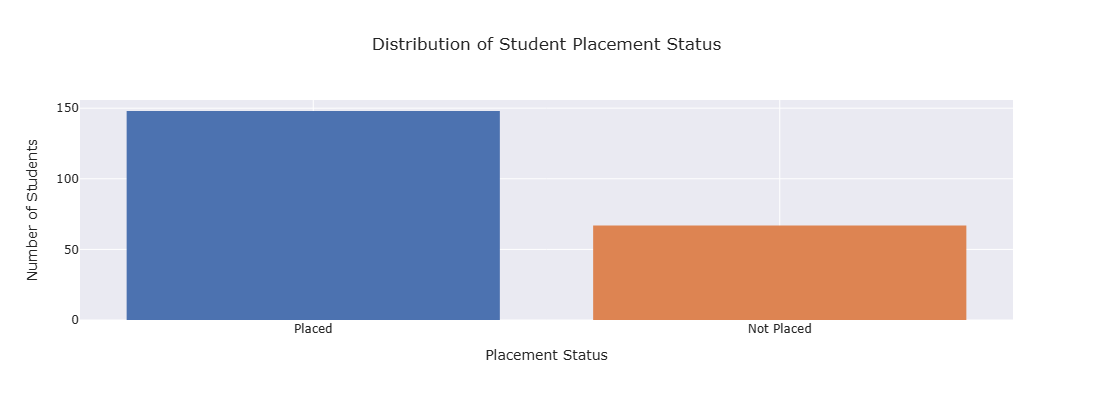

In [96]:
# 4.2 Placement Status Distribution
fig = px.histogram(df, x='status', color='status',
                   title='Distribution of Student Placement Status',
                   labels={'status': 'Placement Status'},
                   template='seaborn', width=600, height=400)
fig.update_layout(yaxis_title='Number of Students', showlegend=False)
fig.show()

> **Quick Observation (Target Variable Analysis):** 
> * Out of 215 total students, **148 are Placed** (approx. 69%) and **67 are Not Placed** (approx. 31%).
> * **ML Takeaway:** There is a moderate class imbalance here (roughly a 2:1 ratio). This imbalance is **not** much to need aggressive data resampling techniques like SMOTE, but we should use stratified splitting (`stratify=y` in `train_test_split`) later on to keep this ratio identical in both training and validation sets.

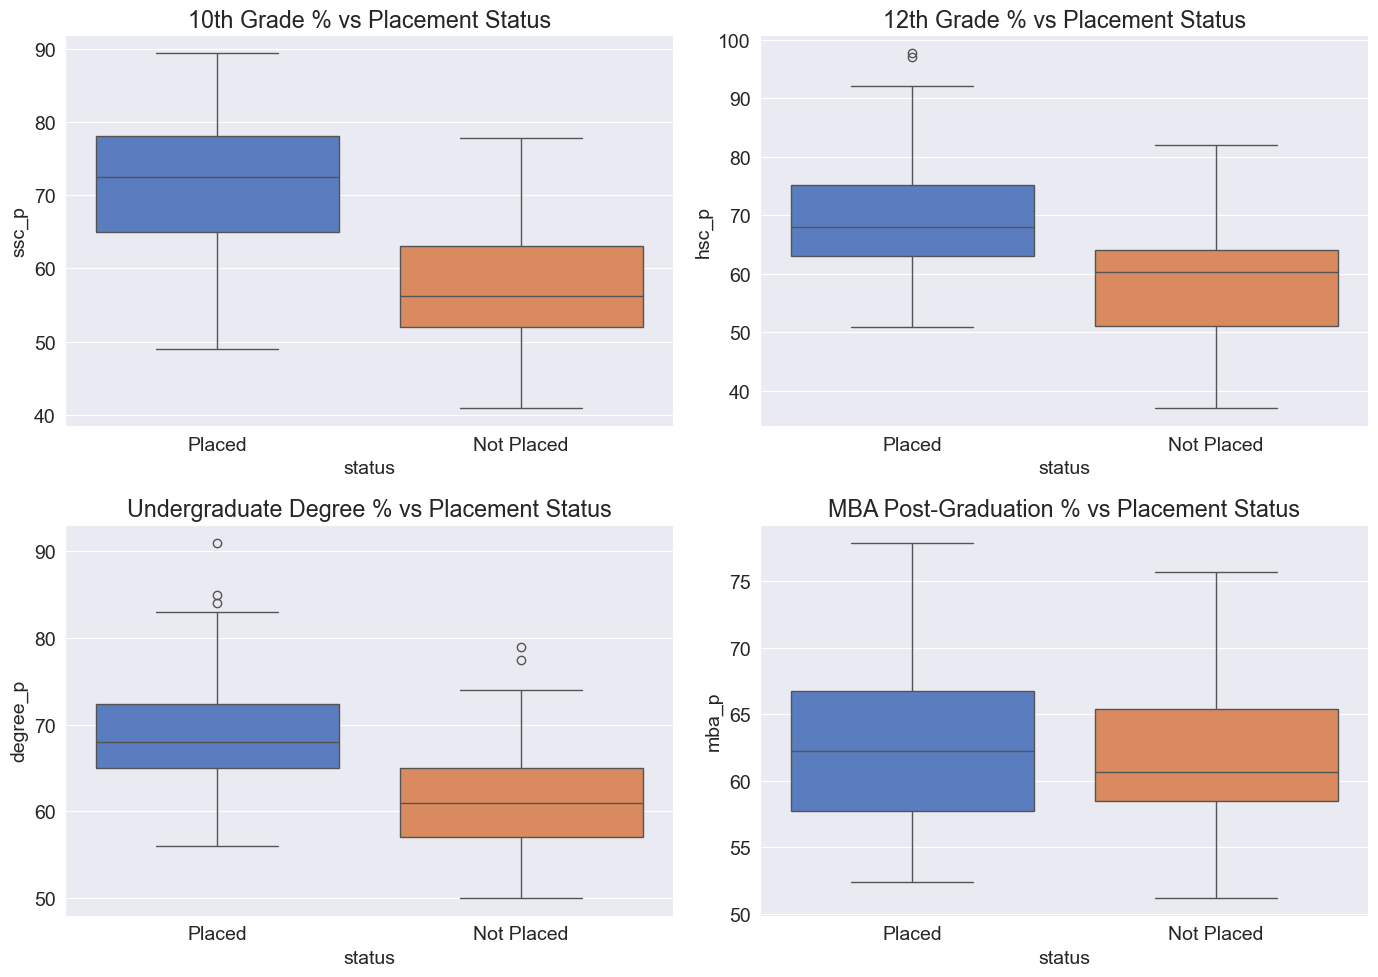

In [97]:
# 4.3 Academic Percentages vs Placement Status
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(ax=axes[0,0], x='status', y='ssc_p', data=df, hue='status', palette='muted', legend=False)
axes[0,0].set_title('10th Grade % vs Placement Status')

sns.boxplot(ax=axes[0,1], x='status', y='hsc_p', data=df, hue='status', palette='muted', legend=False)
axes[0,1].set_title('12th Grade % vs Placement Status')

sns.boxplot(ax=axes[1,0], x='status', y='degree_p', data=df, hue='status', palette='muted', legend=False)
axes[1,0].set_title('Undergraduate Degree % vs Placement Status')

sns.boxplot(ax=axes[1,1], x='status', y='mba_p', data=df, hue='status', palette='muted', legend=False)
axes[1,1].set_title('MBA Post-Graduation % vs Placement Status')

plt.tight_layout()
plt.show()

> **Quick Observation (Academic Performance Analysis):**
> * **10th Grade vs Placement Status:** Students having higher 10th grade percentages have more placement, indicating 10th grade performance may have a positive influence on placement.
> * **12th Grade vs Placement Status:** Students with higher 12th-grade percentages are more likely to be placed, although some overlap exists between the two groups.
> * **Undergraduate Degree vs Placement Status:** Higher the undergraduate marks, better are the placement outcomes which makes degree percentage an important factor.
> * **MBA Post-Graduation vs Placement Status:** MBA percentage does not clearly shows difference between placed and non-placed students, indicating it has a weaker impact on placement.
> * The boxplots also shows **outliers** in 12th-grade(hsc-p) and Undergraduate(degree_p)  percentages. These outliers are reatined instead of being removed as they represent genuine variations in performance instead of data entry errors.

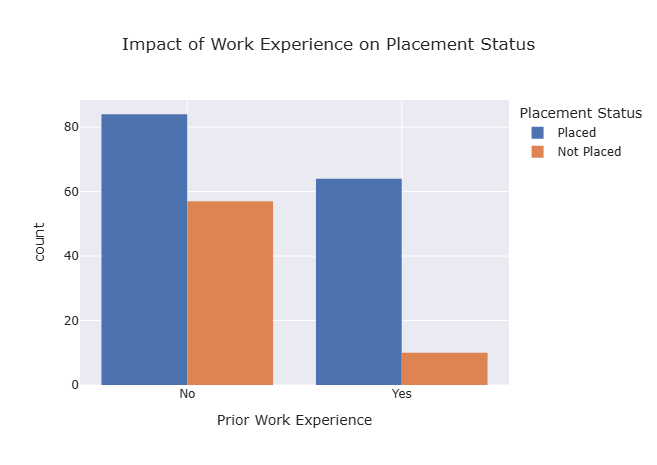

In [98]:
# 4.4 Work Experience and Specialization effect

# Work Experience split by Status
fig1 = px.histogram(df, x="workex", color="status", barmode="group",
                    title="Impact of Work Experience on Placement Status",
                    labels={"workex": "Prior Work Experience", "status": "Placement Status"},
                    template="seaborn", width=700, height=450)
fig1.show()

> **Quick Observation:**
> * Students with work experience are more likely to be placed than those without work experience, suggesting that work experience has a positive impact on placement.


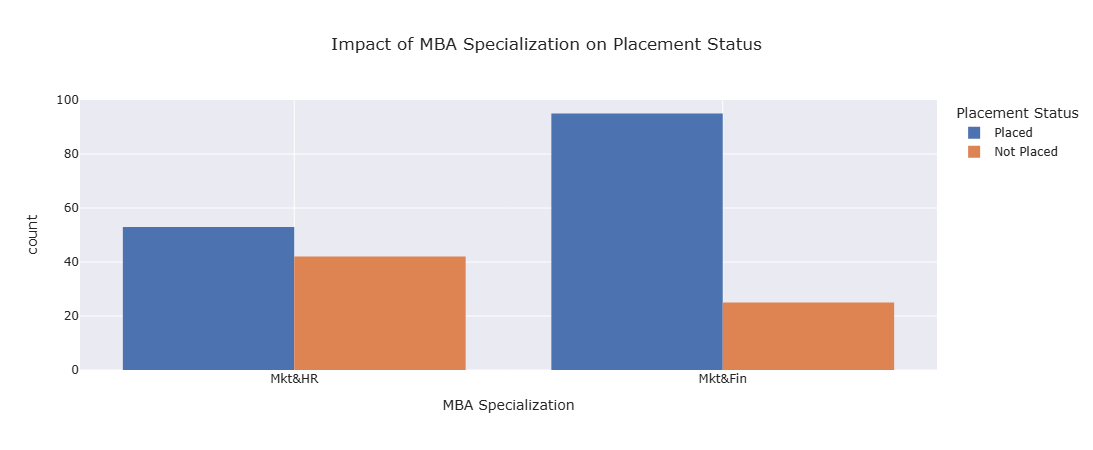

In [99]:
# MBA Specialization split by Status
fig2 = px.histogram(df, x="specialisation", color="status", barmode="group",
                    title="Impact of MBA Specialization on Placement Status",
                    labels={"specialisation": "MBA Specialization", "status": "Placement Status"},
                    template="seaborn", width=700, height=450)
fig2.show()

> **Quick Observation:**
> * Students from the Marketing & Finance specialization have a higher placement rate than those from Marketing & HR, indicating that specialization may play an important role in placement success.


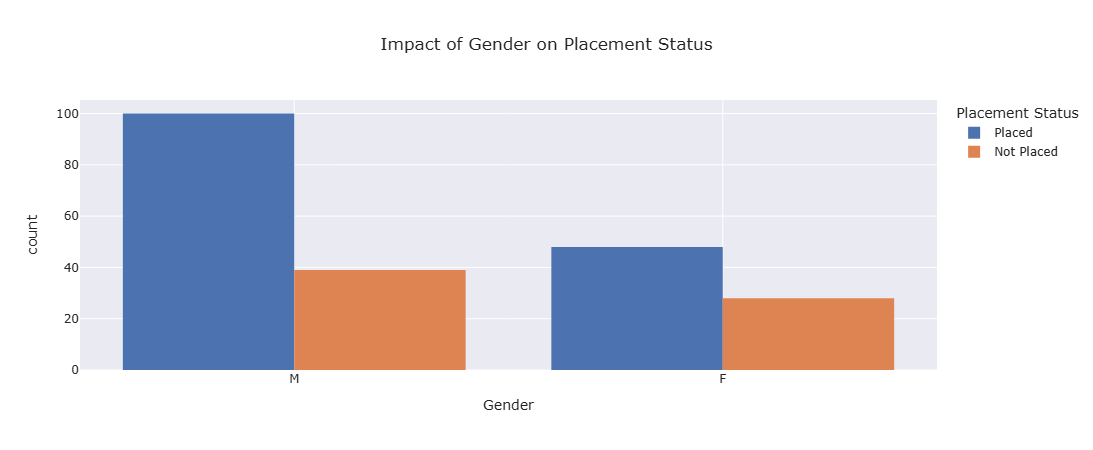

In [108]:
# Gender split by Status
fig3 = px.histogram(df, x="gender", color="status", barmode="group",
                    title="Impact of Gender on Placement Status",
                    labels={"gender": "Gender", "status": "Placement Status"},
                    template="seaborn", width=700, height=450)
fig3.show()

> **Quick Observation**
> * Roughly **72% of male candidates** get placed (100 out of ~139), compared to roughly **63% of female candidates** (48 out of ~76). Both male and female students have more placements than non-placements, suggesting that gender alone is not a significant factor affecting placement status.

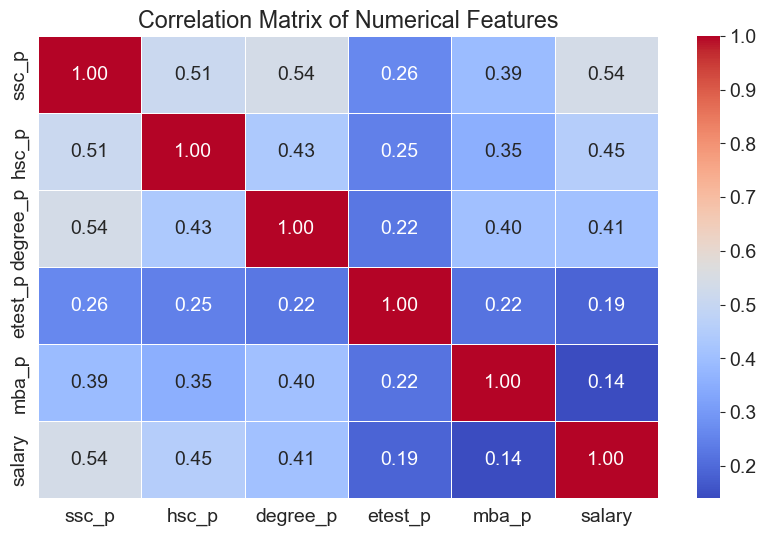

In [109]:
# 4.5 Correlation Matrix
numerical_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

> **Quick Observation:**
> * The correlation matrix indicates that 10th, 12th, and undergraduate percentages have moderate positive correlations with salary, suggesting that students with better academic performance tend to receive higher salary packages. In contrast, MBA percentage and employability test score have weak correlations with salary, indicating that these factors alone have a limited relationship with salary in this dataset.

---
# Preprocessing

### Step 1 : Splitting Features from the Target Variable

In [60]:
# 1.1 Separating features and target variable
# We drop 'salary' to prevent data leakage, and 'status' because it's the target answer.
X = df.drop(columns=['status', 'salary'])
y = df['status']

print("Features Shape (X)")
print(X.shape)
print("\nTarget Shape (y)")
print(y.shape)

Features Shape (X)
(215, 12)

Target Shape (y)
(215,)


The salary column is not used as an input feature for model training because it is known only after placement. Including it would introduce data leakage, leading to unrealistic model performance. Therefore, the salary column is removed before preprocessing and model building.

### Step 2 : Categorical Encoding

In [202]:
# 2.1 Converting categorical columns to numerical columns
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()
binary_cols = ['gender', 'ssc_b', 'hsc_b', 'workex', 'specialisation']

# Apply label encoding to binary features and store encoder states for inference
label_encoders = {}
for col in binary_cols:
    le_col = LabelEncoder()
    X_encoded[col] = le_col.fit_transform(X_encoded[col])
    label_encoders[col] = le_col

# One-hot encode multi-class features and drop the first dummy to avoid multicollinearity
X_encoded = pd.get_dummies(X_encoded, columns=['hsc_s', 'degree_t'], drop_first=True, dtype=int)

# Map target vector to binary space
y_encoded = y.map({'Placed': 1, 'Not Placed': 0})

print("Data Successfully Encoded")
print(X_encoded.head())

Data Successfully Encoded
   gender  ssc_p  ssc_b  hsc_p  hsc_b  degree_p  workex  etest_p  \
0       1  67.00      1  91.00      1     58.00       0     55.0   
1       1  79.33      0  78.33      1     77.48       1     86.5   
2       1  65.00      0  68.00      0     64.00       0     75.0   
3       1  56.00      0  52.00      0     52.00       0     66.0   
4       1  85.80      0  73.60      0     73.30       0     96.8   

   specialisation  mba_p  hsc_s_Commerce  hsc_s_Science  degree_t_Others  \
0               1  58.80               1              0                0   
1               0  66.28               0              1                0   
2               0  57.80               0              0                0   
3               1  59.43               0              1                0   
4               0  55.50               1              0                0   

   degree_t_Sci&Tech  
0                  1  
1                  1  
2                  0  
3               

* **Label Encoding:** Applied to binary features (cardinality = 2) to map values directly to 0 and 1, keeping the feature space compact.
* **One-Hot Encoding (`drop_first=True`):** Applied to multi-class nominal features to prevent the model from assuming a false ordinal ranking. Dropping the first category eliminates redundancy and prevents multicollinearity.

### Step 3 : Train-Test Split

In [153]:
from sklearn.model_selection import train_test_split

# 3.1 Splitting the data into training and testing sets
# We use stratify=y_encoded to keep the 69% / 31% placement split identical in both piles
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print("Train-Test Split Shapes")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

Train-Test Split Shapes
X_train shape: (172, 14)
X_test shape:  (43, 14)
y_train shape: (172,)
y_test shape:  (43,)


### Step 4: Feature Scaling

In [154]:
from sklearn.preprocessing import StandardScaler

# 3.4 Feature Scaling
scaler = StandardScaler()

# Identify the continuous numerical columns that need scaling
numerical_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

# Create copies of our dataframes to hold scaled data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit on training data and transform both training and testing sets
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Feature Scaling Complete")
print("Sample scaled training data:")
print(X_train_scaled[numerical_cols].head())

Feature Scaling Complete
Sample scaled training data:
        ssc_p     hsc_p  degree_p   etest_p     mba_p
147  0.260729  0.694120 -0.166768  0.778647  0.000789
161 -1.065759 -1.405431 -1.192126 -1.123471  0.074478
169 -0.664128 -2.212388 -0.678080 -1.359642  0.536711
131  0.712104 -0.857722 -0.576911  0.553721 -0.250425
27  -0.384091  0.055126 -0.030053 -0.345979 -0.767924


* **Standardization:** For continuous numerical columns such as `ssc_p`, `hsc_p`, etc., we use `StandardScaler` to make data points have a mean of 0 and a standard deviation of 1.
* **Algorithmic Necessity:** Models which use a distance metric (e.g. SVM, KNN) or those which use gradient descent optimization (e.g. Logistic Regression) will be sensitive to magnitude of features. Unscaled features with larger ranges would dominate objective functions disproportionately.
* **Data Leakage Prevention:** Scaler is explicitly `fit_transform` for the training partition, but only `transform` for the test partition. This is to avoid artificially inflating evaluation metrics by future data variance.
---